In [5]:
import geopandas as gpd
import folium
from folium.plugins import HeatMap
from folium import Element

# ======================
# 1. Carregar Dados
# ======================
avenidas = gpd.read_file("avenidas_fortaleza.geojson")
semaforos = gpd.read_file("dadosabertos_semaforosctafor.geojson")
radares = gpd.read_file("dadosabertos_equipfisceletronica.geojson")
sinistros = gpd.read_file("sinistros-2015-2024.geojson")

avenidas = avenidas.sort_values("ranking")

# ======================
# 2. Configuração do Mapa Base
# ======================
mapa = folium.Map(
    location=[-3.7319, -38.5267],
    zoom_start=12,
    tiles=None
)

folium.TileLayer('cartodbdark_matter', name='Mapa Base (Dark)').add_to(mapa)

cores = ["#ff0033", "#ff1a4d", "#ff3366", "#ff4d80", "#ff6699"]

# ======================
# 3. CSS Cyberpunk + Nova Ordem
# ======================
css_cyberpunk = """
<style>
/* A MÁGICA INVERTIDA: 
   Agora o Heatmap fica no fundo (200) e as Avenidas ficam no meio (300).
   Os pontos continuam no topo naturalmente por causa dos panes nativos.
*/
.leaflet-heatmap-layer {
    z-index: 200 !important; 
}
.leaflet-overlay-pane svg {
    z-index: 300 !important;
}

/* Estilos do Card Neon */
.leaflet-control-layers {
    background-color: rgba(10, 10, 12, 0.95) !important;
    border: 1px solid #00ffcc !important;
    box-shadow: 0 0 10px rgba(0, 255, 204, 0.6), inset 0 0 8px rgba(255, 0, 85, 0.4) !important;
    border-radius: 4px !important;
    font-family: 'Courier New', monospace !important;
    padding: 5px;
}
.leaflet-control-layers-base span {
    color: #00ffcc !important;
    text-shadow: 0 0 3px rgba(0, 255, 204, 0.8) !important;
    font-weight: bold;
}
.leaflet-control-layers-overlays span {
    color: #ff0055 !important;
    text-shadow: 0 0 3px rgba(255, 0, 85, 0.8) !important;
    font-weight: bold;
}
.leaflet-control-layers-separator {
    border-top: 1px dashed #00ffcc !important;
    margin: 8px 0 !important;
}
</style>
"""
mapa.get_root().header.add_child(Element(css_cyberpunk))

# ======================
# 4. Camadas 
# ======================

# --- Fundo: Heatmap ---
layer_heat = folium.FeatureGroup(name="Heatmap acidentes")

heat_data = [
    [row.geometry.y, row.geometry.x]
    for _, row in sinistros.iterrows() if row.geometry.geom_type == 'Point'
]

HeatMap(
    heat_data,
    radius=12,
    blur=15
).add_to(layer_heat)

mapa.add_child(layer_heat)

# --- Meio: Avenidas ---
layer_avenidas = folium.FeatureGroup(name="Top 5 Avenidas", show=True)

for _, row in avenidas.iterrows():
    ranking = row["ranking"]
    nome = row["nome"]
    acidentes = row["acidentes"]
    geom = row.geometry
    cor = cores[ranking-1]
    centro = geom.centroid

    folium.Marker(
        location=[centro.y, centro.x],
        icon=folium.DivIcon(
            html=f"""
            <div style="
            width:24px; height:24px; border-radius:50%;
            background:{cor}; color:white; font-size:13px; font-weight:bold;
            text-align:center; line-height:24px; box-shadow:0 0 8px {cor};
            ">
            {ranking}
            </div>
            """
        ),
        pane="shadowPane"
    ).add_to(layer_avenidas)

    linhas = [geom] if geom.geom_type == "LineString" else geom.geoms
    for linha in linhas:
        coords = [(lat, lon) for lon, lat in linha.coords]
        folium.PolyLine(
            coords,
            color=cor,
            weight=8,
            opacity=1.0,
            tooltip=f"{ranking}º - {nome} ({acidentes} acidentes)"
        ).add_to(layer_avenidas)

mapa.add_child(layer_avenidas)

# --- Topo 1: Semáforos ---
layer_semaforos = folium.FeatureGroup(name="Semáforos")

for _, row in semaforos.iterrows():
    lat = row["LATITUDE"]
    lon = row["LONGITUDE"]
    cruz = row["CRUZAMENTO"]

    folium.CircleMarker(
        location=[lat, lon],
        radius=3,
        color="#00ffff", 
        fill=True,
        fill_color="#00ffff",
        fill_opacity=0.8,
        tooltip=cruz,
        pane="markerPane" 
    ).add_to(layer_semaforos)

mapa.add_child(layer_semaforos)

# --- Topo 2: Fiscalização ---
layer_radares = folium.FeatureGroup(name="Fiscalização eletrônica")

for _, row in radares.iterrows():
    lat = row["Lat"]
    lon = row["Lon"]
    endereco = row["Endereco"]

    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color="#ff00ff", 
        fill=True,
        fill_color="#ff00ff",
        fill_opacity=0.9,
        tooltip=endereco,
        pane="tooltipPane" 
    ).add_to(layer_radares)

mapa.add_child(layer_radares)

# ======================
# 5. Finalização
# ======================
folium.LayerControl(collapsed=False).add_to(mapa)

mapa.save("mapa_acidentes_fortaleza_final.html")
print("Tudo certo! Mapa gerado: mapa_acidentes_fortaleza_final.html")

Skipping field HORA: unsupported OGR type: 10


Tudo certo! Mapa gerado: mapa_acidentes_fortaleza_final.html


/tmp/ipykernel_189146/2784543137.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['HORA_INT'] = pd.to_datetime(df['HORA'], errors='coerce').dt.hour


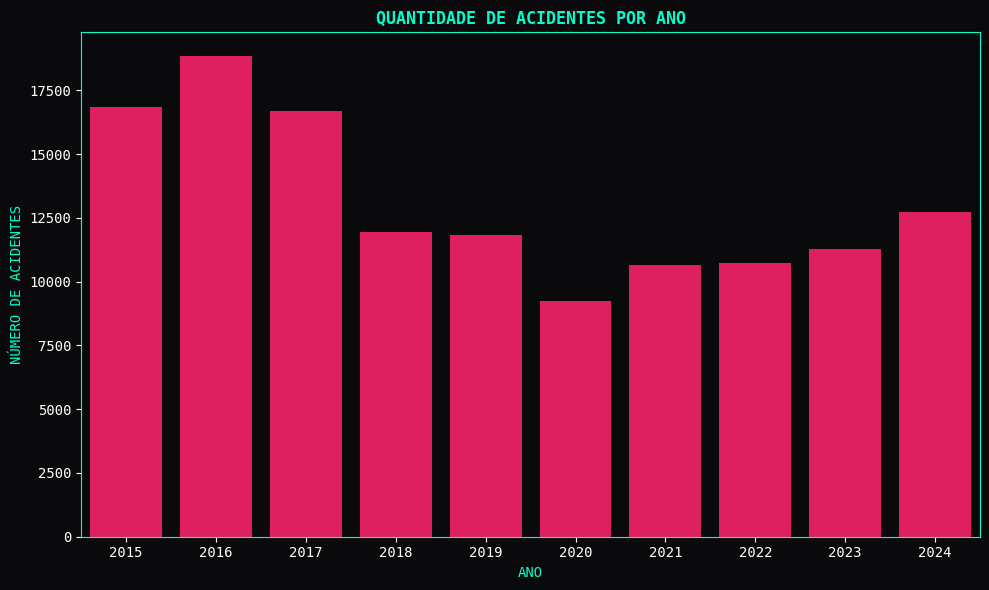

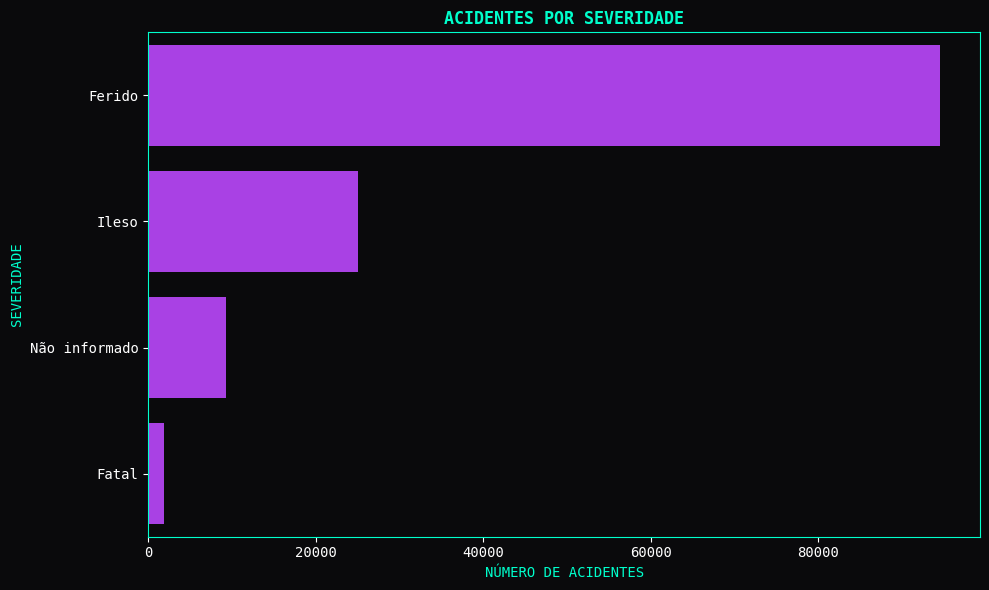

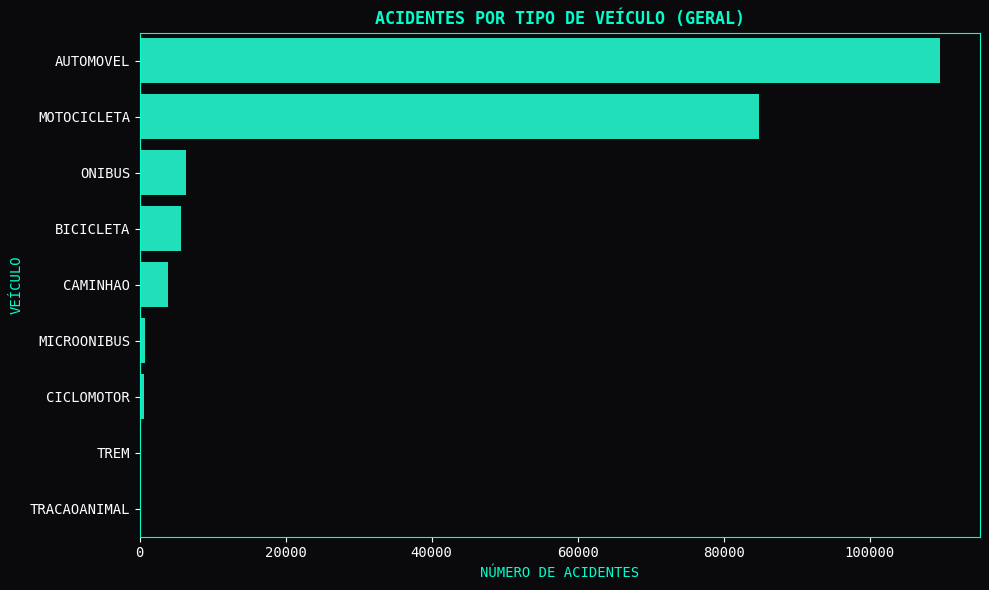

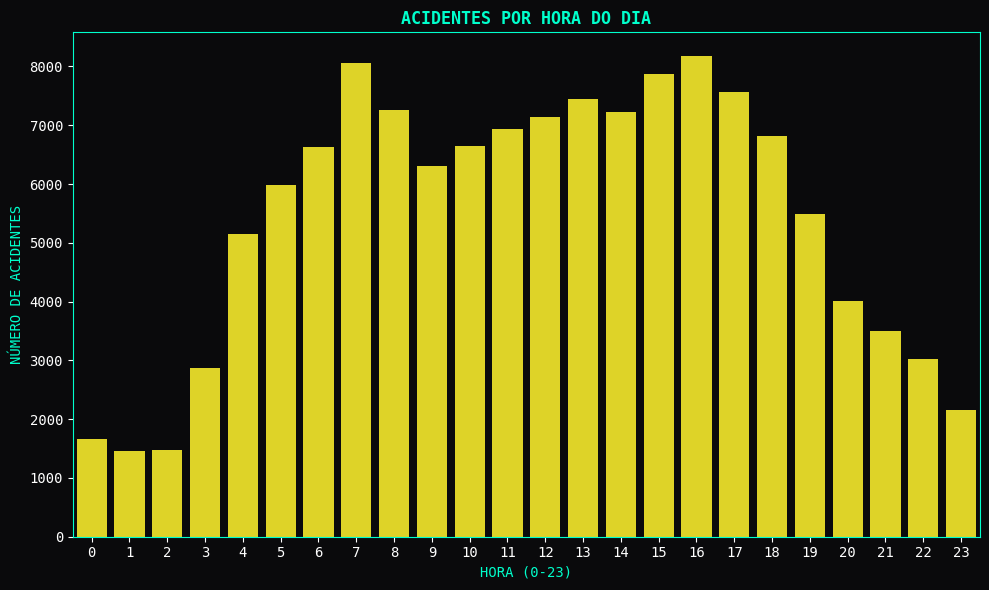

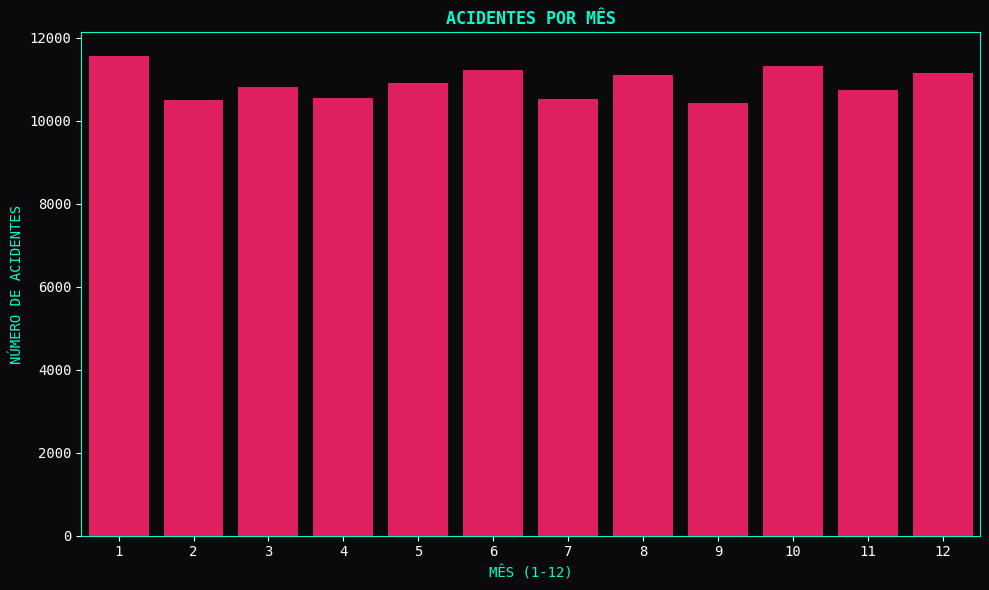

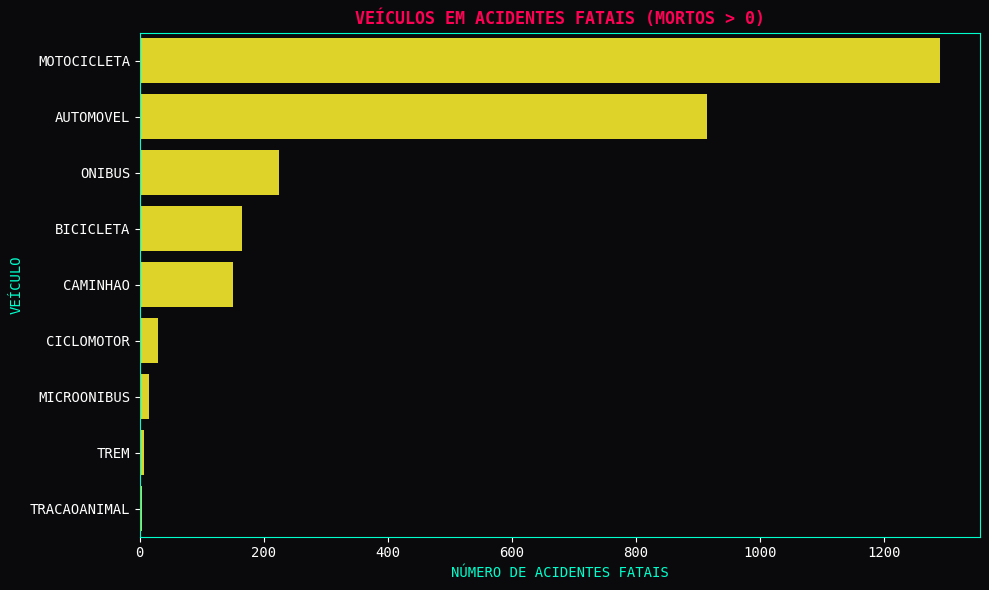

In [6]:
# ======================
# Análise de Sinistros (2015-2024) - Estética Cyberpunk
# ======================

import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# Configuração Visual Cyberpunk
# ======================
plt.style.use("dark_background")

# Cores Neon
neon_cyan = "#00ffcc"
neon_pink = "#ff0055"
neon_yellow = "#fcee0a"
neon_purple = "#b026ff"

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.facecolor": "#0a0a0c",      # Fundo do gráfico bem escuro
    "figure.facecolor": "#0a0a0c",    # Fundo da figura
    "grid.color": neon_cyan,          # Grid ciano
    "grid.alpha": 0.15,               # Grid sutil
    "grid.linestyle": "--",
    "axes.edgecolor": neon_cyan,      # Bordas ciano
    "text.color": "white",
    "axes.labelcolor": neon_cyan,
    "xtick.color": "white",
    "ytick.color": "white",
    "font.family": "monospace"        # Fonte pegada terminal
})

# ======================
# Carregar arquivo GeoJSON
# ======================
with open("sinistros-2015-2024.geojson", "r", encoding="utf-8") as f:
    data = json.load(f)

# normalizar features e limpar nome das colunas
df = pd.json_normalize(data['features'])
df.columns = [c.replace('properties.', '') for c in df.columns]

# ======================
# Tratamento de Dados
# ======================
# Horas
df['HORA'] = df['HORA'].fillna('00:00:00')
df['HORA_INT'] = pd.to_datetime(df['HORA'], errors='coerce').dt.hour

# Severidade nula
df['SEVERIDADE'] = df['SEVERIDADE'].fillna('Não informado')

# Lista padrão de veículos para usar nos gráficos 3 e 6
veiculos = ['AUTOMOVEL', 'ONIBUS', 'BICICLETA', 'CAMINHAO', 'MICROONIBUS', 'CICLOMOTOR', 'MOTOCICLETA', 'TRACAOANIMAL', 'TREM']

# ======================
# Gráfico 1: Acidentes por ano
# ======================
plt.figure()
sns.countplot(x='ANO', data=df, color=neon_pink, order=sorted(df['ANO'].unique()))
plt.title("QUANTIDADE DE ACIDENTES POR ANO", color=neon_cyan, fontweight="bold")
plt.xlabel("ANO")
plt.ylabel("NÚMERO DE ACIDENTES")
plt.tight_layout()
plt.show()

# ======================
# Gráfico 2: Acidentes por severidade
# ======================
plt.figure()
sns.countplot(y='SEVERIDADE', data=df, color=neon_purple, order=df['SEVERIDADE'].value_counts().index)
plt.title("ACIDENTES POR SEVERIDADE", color=neon_cyan, fontweight="bold")
plt.xlabel("NÚMERO DE ACIDENTES")
plt.ylabel("SEVERIDADE")
plt.tight_layout()
plt.show()

# ======================
# Gráfico 3: Acidentes por tipo de veículo (Geral)
# ======================
df_veiculos = df[veiculos].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=df_veiculos.values, y=df_veiculos.index, color=neon_cyan)
plt.title("ACIDENTES POR TIPO DE VEÍCULO (GERAL)", color=neon_cyan, fontweight="bold")
plt.xlabel("NÚMERO DE ACIDENTES")
plt.ylabel("VEÍCULO")
plt.tight_layout()
plt.show()

# ======================
# Gráfico 4: Acidentes por hora do dia
# ======================
plt.figure()
sns.countplot(x='HORA_INT', data=df, color=neon_yellow, order=range(0, 24))
plt.title("ACIDENTES POR HORA DO DIA", color=neon_cyan, fontweight="bold")
plt.xlabel("HORA (0-23)")
plt.ylabel("NÚMERO DE ACIDENTES")
plt.tight_layout()
plt.show()

# ======================
# Gráfico 5: Acidentes por mês
# ======================
plt.figure()
sns.countplot(x='MES', data=df, color=neon_pink, order=range(1, 13))
plt.title("ACIDENTES POR MÊS", color=neon_cyan, fontweight="bold")
plt.xlabel("MÊS (1-12)")
plt.ylabel("NÚMERO DE ACIDENTES")
plt.tight_layout()
plt.show()

# ======================
# Gráfico 6: Veículos em acidentes FATAIS (A prova real)
# ======================
# Filtramos apenas as ocorrências onde houve pelo menos 1 morto
df_fatal = df[df['MORTOS'] > 0]
df_veiculos_fatal = df_fatal[veiculos].sum().sort_values(ascending=False)

plt.figure()
# Usando amarelo para alertar/destacar a fatalidade
sns.barplot(x=df_veiculos_fatal.values, y=df_veiculos_fatal.index, color=neon_yellow)
plt.title("VEÍCULOS EM ACIDENTES FATAIS (MORTOS > 0)", color=neon_pink, fontweight="bold")
plt.xlabel("NÚMERO DE ACIDENTES FATAIS")
plt.ylabel("VEÍCULO")
plt.tight_layout()
plt.show()